# Learning Stochastic Dynamics with the Continuous Unscented Transform

**From noisy trajectories to calibrated uncertainty bands — a NeuroMANCER tutorial**

This notebook walks through a realistic workflow for modelling a stochastic
dynamical system end-to-end:

1. **Data generation** — simulate noisy Van der Pol trajectories via Euler–Maruyama
2. **Current capability** — train a standard NeuroMANCER neural ODE on the noisy data
3. **The gap** — a neural ODE gives a point forecast; it cannot tell you *how uncertain* the prediction is
4. **ContinuousUT framework** — propagate uncertainty through the learned (or known) dynamics
   - *Use Case 2*: known whitebox drift + learn diffusion
   - *Use Case 2b*: plug the trained neural ODE in as drift + learn diffusion
   - *Use Case 3*: learn both drift and diffusion from data

Built on [NeuroMANCER](https://github.com/pnnl/neuromancer) (`Block`, `Node`, `System`, `Trainer`, `Problem`, `MLP`, `integrators`).

### References

1. Julier & Uhlmann, "Unscented filtering and nonlinear estimation," *Proc. IEEE*, 2004.
2. O'Leary, Paulson & Mesbah, "SPINN: A moment-matching framework for learning hidden physics within SDEs," *arXiv:2109.01621*, 2021.


## Setup

Uncomment the cell below if running on Colab or a fresh environment.


In [ ]:
# !pip install "neuromancer[examples] @ git+https://github.com/pnnl/neuromancer.git@master"


## Imports

In [3]:
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from typing import Optional, List, Tuple
from dataclasses import dataclass

# NeuroMANCER core
from neuromancer.system import Node, System
from neuromancer.dynamics import integrators
from neuromancer.trainer import Trainer
from neuromancer.problem import Problem
from neuromancer.loggers import BasicLogger
from neuromancer.dataset import DictDataset
from neuromancer.constraint import variable
from neuromancer.loss import PenaltyLoss
from neuromancer.modules import blocks as nm_blocks

# ContinuousUT module
from continuous_ut import (
    ContinuousUT,
    TrainingConfig,
    UTConfig,
    NetworkConfig,
    PropagationResult,
    PreciseLogger,
    simulate_sde,
    generate_moment_data,
)

torch.manual_seed(42)
np.random.seed(42)
print("Imports OK")


Imports OK


---
# Part 1: The Stochastic Van der Pol Oscillator

The Van der Pol oscillator is a classic nonlinear system with a stable limit cycle.
We add **additive diffusion noise** to create a stochastic version:

$$
\mathrm{d}x_1 = x_2 \, \mathrm{d}t + \sigma \, \mathrm{d}W_1
$$
$$
\mathrm{d}x_2 = \big[\mu (1 - x_1^2) x_2 - x_1\big] \mathrm{d}t + \sigma \, \mathrm{d}W_2
$$

with $\mu = 1.0$ and $\sigma = 0.1$.

**Why this matters:** In practice, every dynamical system has unmodelled noise — sensor
error, environmental disturbances, unresolved sub-scale physics.  A model that ignores
this noise gives overconfident predictions.  We want to learn both the
deterministic drift *and* the stochastic diffusion.


## 1.1 Ground truth drift

In [4]:
class VanDerPolDrift(nn.Module):
    """Ground truth Van der Pol drift for data generation."""
    def __init__(self, mu=1.0):
        super().__init__()
        self.mu = mu

    def forward(self, x):
        x1, x2 = x[..., 0], x[..., 1]
        return torch.stack([x2, self.mu * (1 - x1**2) * x2 - x1], dim=-1)

gt_drift = VanDerPolDrift(mu=1.0)
sigma_true = 0.1
nx = 2
dt = 0.01
print(f"System: Van der Pol (mu=1.0), sigma={sigma_true}, nx={nx}, dt={dt}")


System: Van der Pol (mu=1.0), sigma=0.1, nx=2, dt=0.01


## 1.2 Simulate stochastic trajectories

We simulate raw noisy trajectories via **Euler–Maruyama** — this is the kind
of data you'd have in practice from experiments or sensors.


In [5]:
def simulate_stochastic_trajectories(drift_fn, sigma, nx, n_traj, n_steps, dt,
                                      x0_mean=None, x0_std=0.5, seed=42):
    """Euler-Maruyama simulation returning raw trajectories [n_traj, n_steps+1, nx]."""
    np.random.seed(seed)
    if x0_mean is None:
        x0_mean = np.zeros(nx)
    trajectories = np.zeros((n_traj, n_steps + 1, nx))
    sigmas = np.array([sigma] * nx)
    for i in range(n_traj):
        x = x0_mean + x0_std * np.random.randn(nx)
        trajectories[i, 0] = x
        with torch.no_grad():
            for t in range(n_steps):
                drift = drift_fn(torch.tensor(x, dtype=torch.float32).unsqueeze(0))
                drift = drift.squeeze(0).numpy()
                dW = np.random.randn(nx) * np.sqrt(dt)
                x = x + drift * dt + sigmas * dW
                trajectories[i, t + 1] = x
    return trajectories

n_traj = 200
n_steps_per_traj = 200  # 2 seconds at dt=0.01

print("Generating stochastic trajectories...")
trajs = simulate_stochastic_trajectories(
    gt_drift, sigma_true, nx, n_traj, n_steps_per_traj, dt,
    x0_mean=np.array([2.0, 0.0]), x0_std=0.5,
)
print(f"Trajectories shape: {trajs.shape}  (n_traj, n_steps+1, nx)")


Generating stochastic trajectories...
Trajectories shape: (200, 201, 2)  (n_traj, n_steps+1, nx)


## 1.3 Visualise the raw data

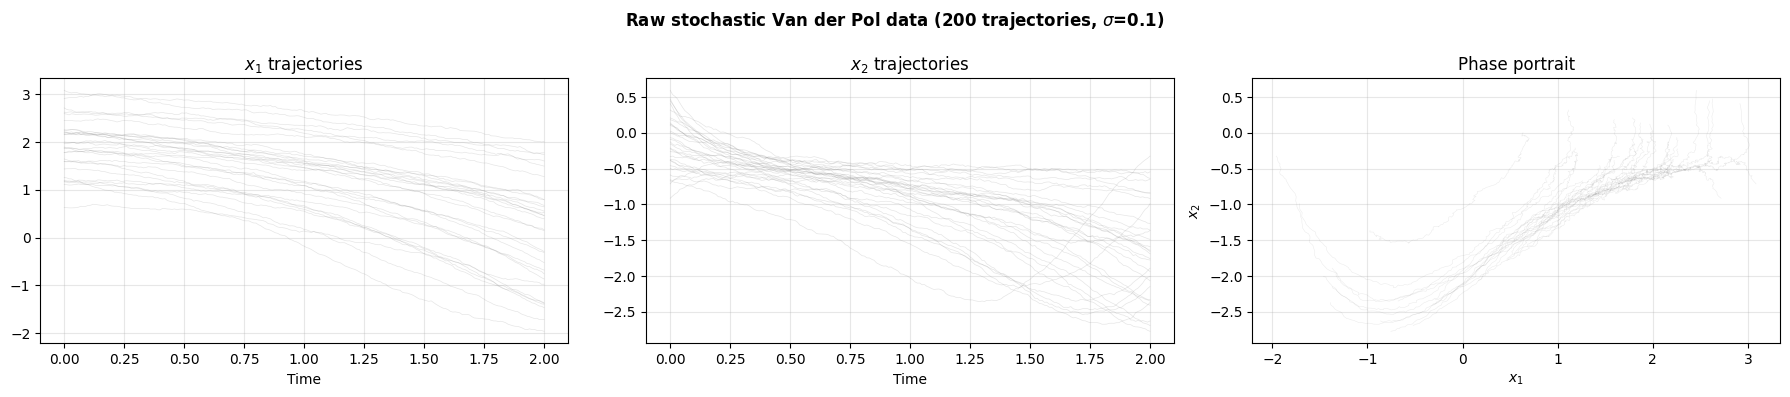

Empirical mean at t=0:  [ 1.9781176  -0.10308032]
Empirical var  at t=0:  [0.2422049  0.20580865]
Empirical mean at t=2s: [ 0.19003172 -1.64441148]
Empirical var  at t=2s: [1.15190295 0.45989305]


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
time_axis = np.arange(n_steps_per_traj + 1) * dt

# Time series
for i in range(min(30, n_traj)):
    axes[0].plot(time_axis, trajs[i, :, 0], "gray", alpha=0.2, lw=0.5)
    axes[1].plot(time_axis, trajs[i, :, 1], "gray", alpha=0.2, lw=0.5)
axes[0].set_title("$x_1$ trajectories"); axes[0].set_xlabel("Time"); axes[0].grid(True, alpha=0.3)
axes[1].set_title("$x_2$ trajectories"); axes[1].set_xlabel("Time"); axes[1].grid(True, alpha=0.3)

# Phase portrait
for i in range(min(30, n_traj)):
    axes[2].plot(trajs[i, :, 0], trajs[i, :, 1], "gray", alpha=0.15, lw=0.4)
axes[2].set_title("Phase portrait"); axes[2].set_xlabel("$x_1$"); axes[2].set_ylabel("$x_2$")
axes[2].grid(True, alpha=0.3)

plt.suptitle(f"Raw stochastic Van der Pol data ({n_traj} trajectories, $\sigma$={sigma_true})",
             fontweight="bold")
plt.tight_layout(); plt.show()

# Empirical statistics
mu_emp = trajs.mean(axis=0)
var_emp = trajs.var(axis=0)
print(f"Empirical mean at t=0:  {mu_emp[0]}")
print(f"Empirical var  at t=0:  {var_emp[0]}")
print(f"Empirical mean at t=2s: {mu_emp[-1]}")
print(f"Empirical var  at t=2s: {var_emp[-1]}")


---
# Part 2: Standard NeuroMANCER Neural ODE

The standard approach in NeuroMANCER is to train a **neural ODE** to learn
the drift dynamics from the trajectory data.  This follows the familiar
`MLP → RK4 → Node → System → Problem → Trainer` pipeline.

This works well for learning the *mean* dynamics, but the neural ODE gives
you a **single deterministic trajectory** — it has no concept of variance
or uncertainty.  We'll see this gap clearly after training.


## 2.1 Prepare data for neural ODE training

In [7]:
nsteps_node = 2  # one-step prediction windows

def trajectories_to_neuromancer_data(trajs, nsteps, batch_size=100):
    """Chop trajectories into windows for neuromancer training."""
    n_traj, T, nx_dim = trajs.shape
    windows = []
    for i in range(n_traj):
        n_windows = (T - 1) // nsteps
        for j in range(n_windows):
            start = j * nsteps
            windows.append(trajs[i, start:start + nsteps + 1])
    windows = np.array(windows)
    print(f"  Created {len(windows)} windows of length {nsteps + 1}")

    idx = np.random.permutation(len(windows))
    n_train = int(0.8 * len(idx))
    train_w = torch.tensor(windows[idx[:n_train]], dtype=torch.float32)
    dev_w = torch.tensor(windows[idx[n_train:]], dtype=torch.float32)

    train_data = DictDataset({"X": train_w, "xn": train_w[:, 0:1, :]}, name="train")
    dev_data = DictDataset({"X": dev_w, "xn": dev_w[:, 0:1, :]}, name="dev")
    train_loader = DataLoader(train_data, batch_size=batch_size,
                              collate_fn=train_data.collate_fn, shuffle=True)
    dev_loader = DataLoader(dev_data, batch_size=batch_size,
                            collate_fn=dev_data.collate_fn, shuffle=False)
    test_traj = torch.tensor(trajs[0:1], dtype=torch.float32)
    test_data = {"X": test_traj, "xn": test_traj[:, 0:1, :]}
    return train_loader, dev_loader, test_data

print("Preparing neural ODE training data...")
node_train, node_dev, node_test = trajectories_to_neuromancer_data(trajs, nsteps_node)
print(f"  Train batches: {len(node_train)}, Dev batches: {len(node_dev)}")


Preparing neural ODE training data...
  Created 20000 windows of length 3
  Train batches: 160, Dev batches: 40


In [19]:
foo = next(iter(node_train))
foo['xn'].shape

torch.Size([100, 1, 2])

## 2.2 Define and train the neural ODE

In [20]:
# Neural network for ODE RHS
fx = nm_blocks.MLP(
    nx, nx, bias=True,
    linear_map=torch.nn.Linear,
    nonlin=torch.nn.SiLU,
    hsizes=[64, 64, 64],
)
nsteps_node = 3

# Integrate with RK4
fxRK4 = integrators.RK4(fx, h=dt)

# NeuroMANCER pipeline
node_model = Node(fxRK4, ["xn"], ["xn"], name="NeuralODE")
node_system = System([node_model], name="node_system", nsteps=nsteps_node)

# Loss: trajectory tracking + finite differences
x_true = variable("X")
x_pred = variable("xn")[:, :-1, :]
xFD = x_true[:, 1:, :] - x_true[:, :-1, :]
xhatFD = x_pred[:, 1:, :] - x_pred[:, :-1, :]

ref_loss = (x_pred == x_true) ^ 2
ref_loss.name = "ref_loss"
fd_loss = 2.0 * (xFD == xhatFD) ^ 2
fd_loss.name = "fd_loss"

node_loss = PenaltyLoss([ref_loss, fd_loss], [])
node_problem = Problem([node_system], node_loss)

print(f"Neural ODE parameters: {sum(p.numel() for p in fx.parameters()):,}")


Neural ODE parameters: 8,642


In [21]:
# Train
node_optimizer = torch.optim.Adam(node_problem.parameters(), lr=1e-3)
node_logger = PreciseLogger(
    args=None, savedir="./logs_node", verbosity=10,
    stdout=["dev_loss", "train_loss"], precision=6,
)
node_trainer = Trainer(
    node_problem, node_train, node_dev, node_test, node_optimizer,
    patience=30, warmup=20, epochs=200,
    eval_metric="dev_loss", train_metric="train_loss",
    dev_metric="dev_loss", test_metric="dev_loss",
    logger=node_logger,
)
best_node = node_trainer.train()
node_problem.load_state_dict(best_node)
print("Neural ODE training complete.")


None
Number of parameters: 8642
epoch: 0	train_loss: 3.203755e-04	dev_loss: 3.510565e-04
epoch: 10	train_loss: 2.953504e-04	dev_loss: 3.151156e-04
epoch: 20	train_loss: 3.190624e-04	dev_loss: 3.141433e-04
Interrupted training loop.
Neural ODE training complete.


## 2.3 Evaluate the neural ODE

The neural ODE learns the *drift* well — it gives accurate mean trajectory predictions.
But watch what happens: **we get a single line, not an uncertainty band.**


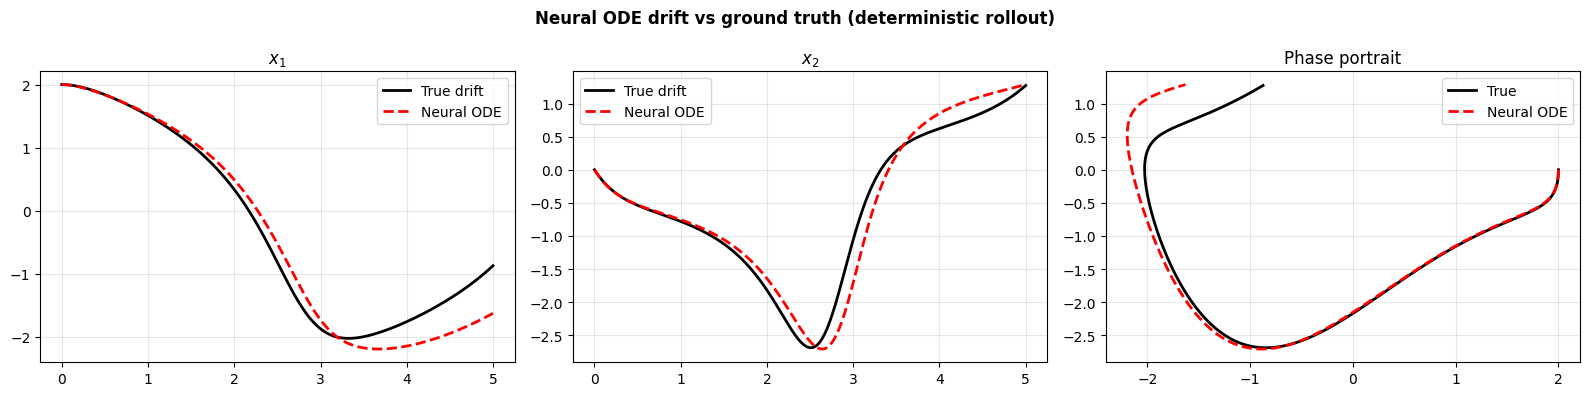


⚠️  The neural ODE gives a SINGLE trajectory — no uncertainty quantification.
    If the initial condition or system has noise, this forecast is overconfident.


In [22]:
fx.eval(); gt_drift.eval()

# Deterministic rollout comparison
x_test = torch.tensor([[2.0, 0.0]], dtype=torch.float32)
traj_learned, traj_true = [x_test[0].numpy()], [x_test[0].numpy()]
x_l, x_t = x_test.clone(), x_test.clone()
with torch.no_grad():
    for _ in range(500):
        x_l = x_l + dt * fx(x_l)
        x_t = x_t + dt * gt_drift(x_t)
        traj_learned.append(x_l[0].numpy())
        traj_true.append(x_t[0].numpy())
traj_learned = np.array(traj_learned)
traj_true = np.array(traj_true)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
time_eval = np.arange(501) * dt
axes[0].plot(time_eval, traj_true[:, 0], "k-", lw=2, label="True drift")
axes[0].plot(time_eval, traj_learned[:, 0], "r--", lw=2, label="Neural ODE")
axes[0].set_title("$x_1$"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(time_eval, traj_true[:, 1], "k-", lw=2, label="True drift")
axes[1].plot(time_eval, traj_learned[:, 1], "r--", lw=2, label="Neural ODE")
axes[1].set_title("$x_2$"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].plot(traj_true[:, 0], traj_true[:, 1], "k-", lw=2, label="True")
axes[2].plot(traj_learned[:, 0], traj_learned[:, 1], "r--", lw=2, label="Neural ODE")
axes[2].set_title("Phase portrait"); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.suptitle("Neural ODE drift vs ground truth (deterministic rollout)", fontweight="bold")
plt.tight_layout(); plt.show()

print("\n⚠️  The neural ODE gives a SINGLE trajectory — no uncertainty quantification.")
print("    If the initial condition or system has noise, this forecast is overconfident.")


---
# Part 3: The Gap — Why We Need Uncertainty Propagation

The neural ODE learned the drift well, but consider what happens in practice:

- **Initial condition uncertainty**: We never know $x_0$ exactly
- **Process noise**: The system has stochastic forcing ($\sigma = 0.1$)
- **Downstream decisions**: Control, safety analysis, and planning all need *confidence bands*, not point predictions

A standard neural ODE rollout gives **zero** information about any of this.
The ContinuousUT framework fills this gap by propagating the *mean and covariance*
simultaneously through the dynamics — at the cost of a single deterministic ODE
integration (no Monte Carlo).


---
# Part 4: ContinuousUT — Use Case 2: Learn Diffusion with Known Drift

**Scenario:** We know the drift (the whitebox Van der Pol equations), but we
don't know the diffusion strength. We want to learn $g_{2,\theta_2}$ from data.

**Recipe:**
```python
model = ContinuousUT.from_known_drift(drift_fn, nx, dt)
model.fit(train_loader, dev_loader, dev_data, sigma_from_data=...)
result = model.propagate(mu0, var0, n_steps)
```

- $g_1$ = known drift (frozen `DriftWrapper`)
- $g_2 = g_{2,\theta_2}$ = `LearnableG2` MLP (trained)
- Only $\theta_2$ is optimised


## 4.1 Generate moment-transition training data

The ContinuousUT trains on **moment transitions**: consecutive
$(\mathbf{m}_t, \mathbf{v}_t) \to (\mathbf{m}_{t+1}, \mathbf{v}_{t+1})$
pairs computed from Monte Carlo ensembles.


In [23]:
print("Generating moment-transition data for Use Case 2...")
train_loader2, dev_loader2, dev_data2, (xn2, xn_next2) = generate_moment_data(
    drift_fn=gt_drift, sigma=sigma_true, nx=nx, base_x0=np.array([2.0, 0.0]),
    n_ensembles=256, n_particles=256, t_per_ensemble=2.0,
    dt=dt, batch_size=64, seed=42,
)


Generating moment-transition data for Use Case 2...
  Ensembles: 51/256
  Ensembles: 102/256
  Ensembles: 153/256
  Ensembles: 204/256
  Ensembles: 255/256
  Data: 40960 train, 10240 dev


## 4.2 Train: learn $g_{2,\theta_2}$ with known drift

In [24]:
model2 = ContinuousUT.from_known_drift(
    drift_fn=gt_drift, nx=nx, dt=dt,
    train_cfg=TrainingConfig(
        g1_warmup_epochs=0,   # no warmup needed — drift is known
        joint_epochs=100,
        patience=20,
        verbosity=10,
    ),
)
model2.summary()

model2.fit(train_loader2, dev_loader2, dev_data2,
           sigma_from_data=(xn2, xn_next2))


ContinuousUT [Learn Diffusion]
  nx=2  dt=0.01  g1=fixed  g2=learned
  params: g1=0  g2=4,482  trainable=4,482
  integrator: neuromancer RK4(h=0.01)
  trained: False
Estimated sigma: 0.1754 (per dim: [0.18881603 0.16204935])

Phase 2: Training g2 only (drift fixed) (100 epochs)
None
Number of parameters: 4482
epoch: 0	train_loss: 7.9400035702e-07	dev_loss: 6.1860606593e-07
epoch: 10	train_loss: 5.4857389387e-07	dev_loss: 5.9564246158e-07
Interrupted training loop.
Training complete.


## 4.3 Evaluate: UT vs Monte Carlo

Mean MSE (vs 10k-particle MC):     0.004108
Variance MSE (vs 10k-particle MC): 0.011056


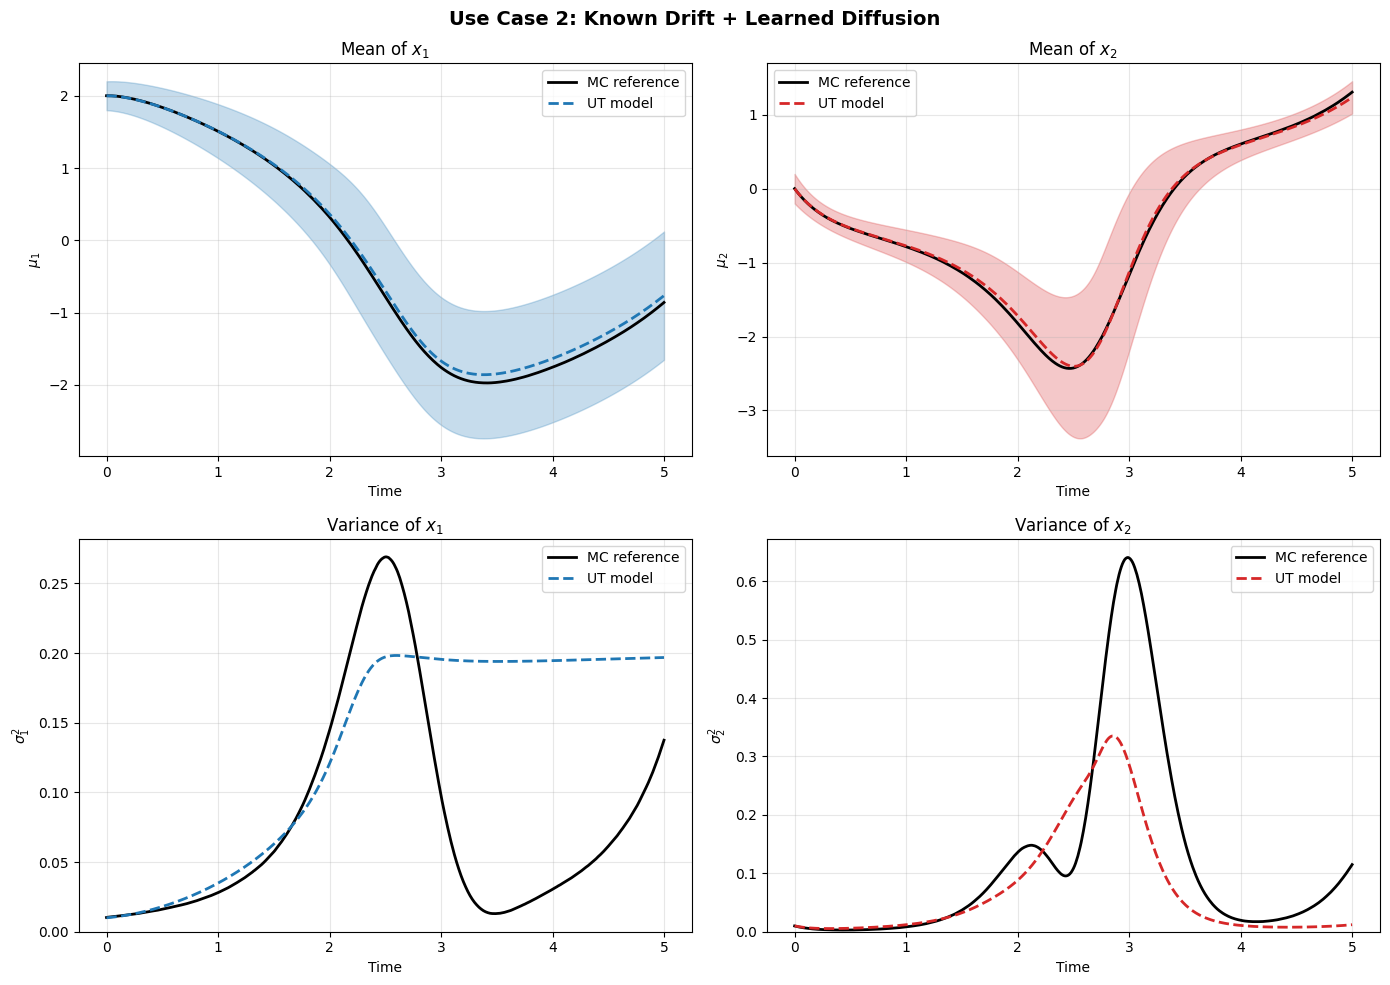

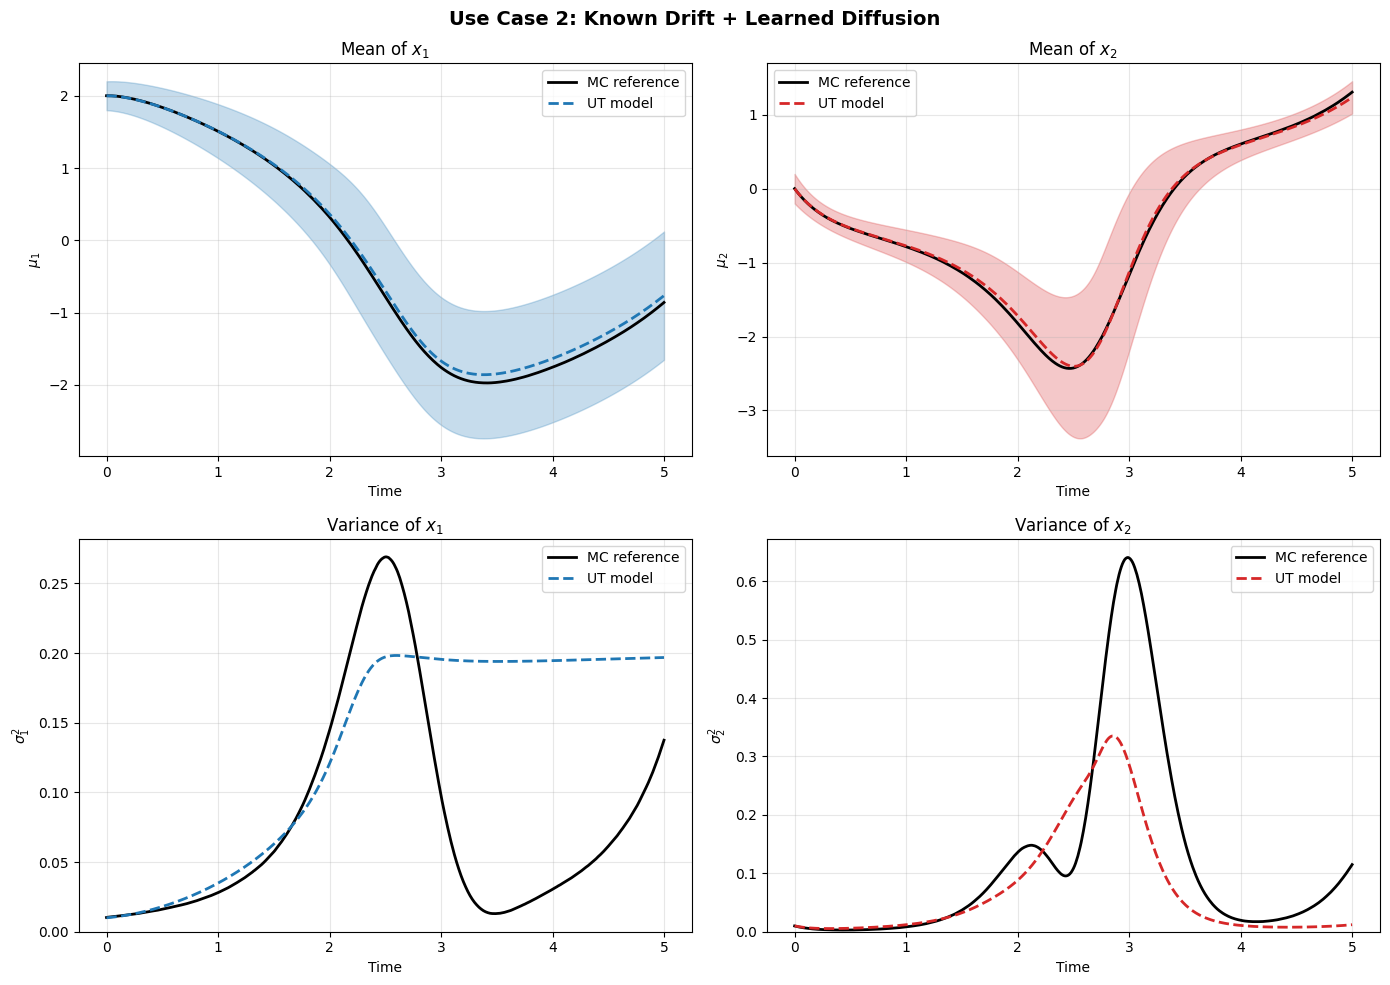

In [25]:
mu0 = [2.0, 0.0]
var0 = [0.01, 0.01]

result2 = model2.propagate(mu0, var0, n_steps=500)
mc2 = simulate_sde(gt_drift, [sigma_true]*nx, mu0, var0, 5.0, dt,
                    n_particles=10000, seed=42)

mse_mu = np.mean((result2.mu - mc2.mu)**2)
mse_var = np.mean((result2.var - mc2.var)**2)
print(f"Mean MSE (vs 10k-particle MC):     {mse_mu:.6f}")
print(f"Variance MSE (vs 10k-particle MC): {mse_var:.6f}")

model2.plot(result2, reference=mc2,
            title="Use Case 2: Known Drift + Learned Diffusion",
            dim_names=["$x_1$", "$x_2$"])


---
# Part 5: ContinuousUT — Use Case 2b: Neural ODE as Drift + Learn Diffusion

This is the **real-world workflow**: we don't have whitebox equations, but we
*do* have a trained neural ODE from Part 2.  We plug it in as $g_1$ and learn
the diffusion $g_{2,\theta_2}$ on top.

**Pipeline:**
```
Stochastic data → Train Neural ODE (θ₁) → freeze θ₁ → ContinuousUT.from_known_drift(fx) → fit(θ₂) → propagate
```

### IC uncertainty through the neural ODE (no diffusion yet)

First, even before learning diffusion, we can already use the neural ODE with
`ContinuousUT.from_known_dynamics()` (Use Case 1) to propagate initial-condition
uncertainty through the learned drift.  A standard neural ODE rollout cannot do this.


ContinuousUT [Propagate IC]
  nx=2  dt=0.01  g1=fixed  g2=fixed
  params: g1=8,642  g2=0  trainable=8,642
  integrator: neuromancer RK4(h=0.01)
  trained: True


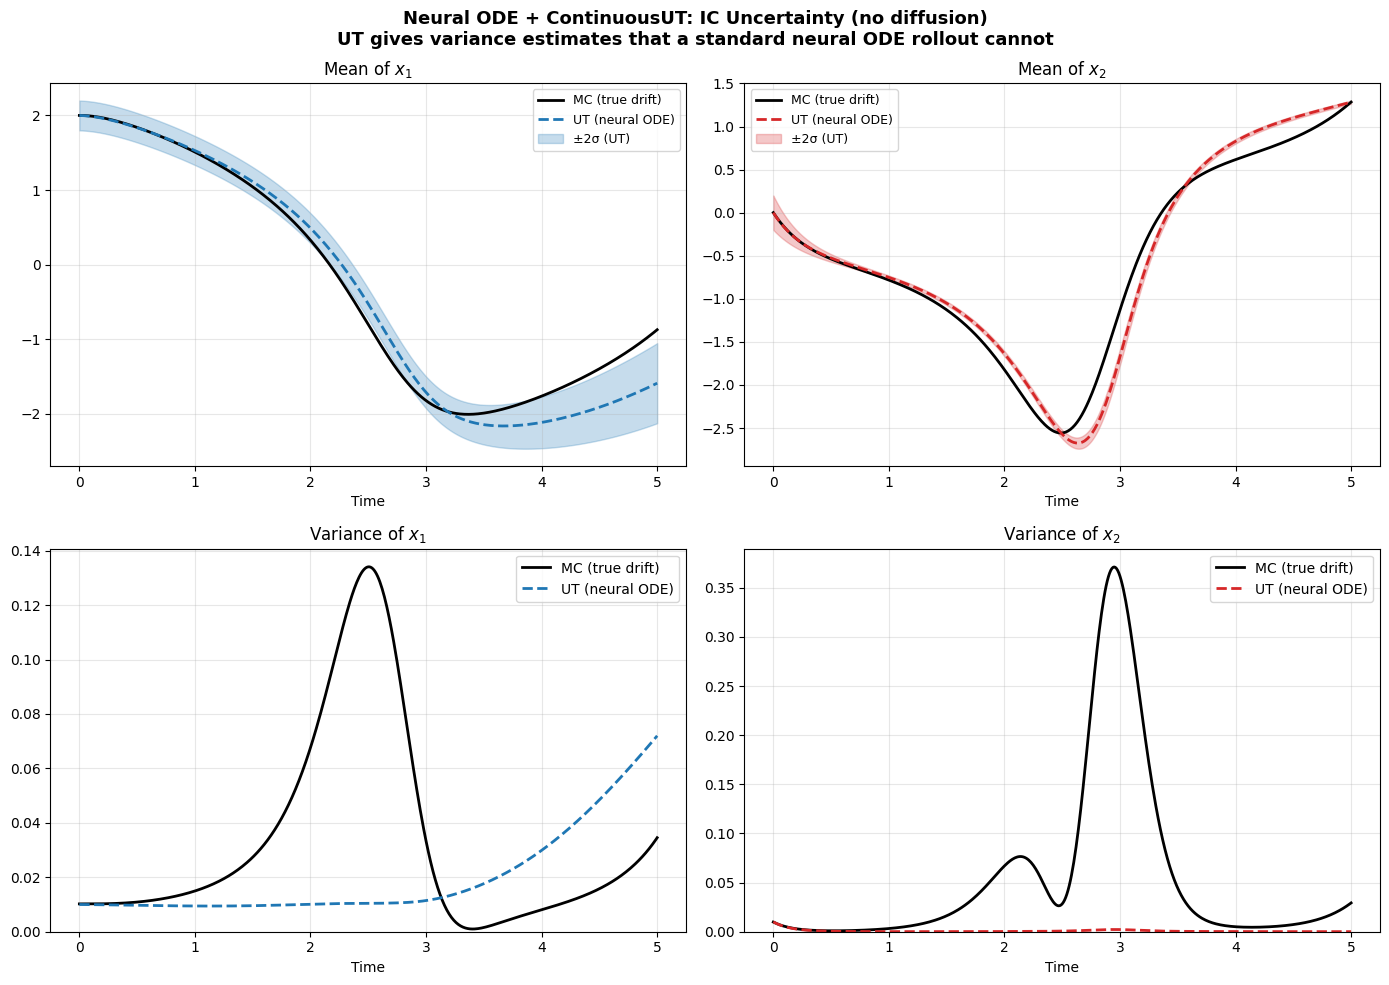

In [26]:
# Use Case 1 with the neural ODE: propagate IC uncertainty, no diffusion
model_node_uc1 = ContinuousUT.from_known_dynamics(fx, nx=nx, dt=dt)
model_node_uc1.summary()

result_node_uc1 = model_node_uc1.propagate([2.0, 0.0], [0.01, 0.01], n_steps=500)
mc_node_uc1 = simulate_sde(gt_drift, [0.0, 0.0], [2.0, 0.0], [0.01, 0.01],
                            5.0, dt, n_particles=10000, seed=42)

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
lo, hi = result_node_uc1.confidence_band(2)
for d, (c, label) in enumerate([("tab:blue", "$x_1$"), ("tab:red", "$x_2$")]):
    ax = axes[0, d]
    ax.plot(mc_node_uc1.time, mc_node_uc1.mu[:, d], "k-", lw=2, label="MC (true drift)")
    ax.plot(result_node_uc1.time, result_node_uc1.mu[:, d], "--", color=c, lw=2, label="UT (neural ODE)")
    ax.fill_between(result_node_uc1.time, lo[:, d], hi[:, d], alpha=0.25, color=c, label="±2σ (UT)")
    ax.set_xlabel("Time"); ax.set_title(f"Mean of {label}"); ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
    ax = axes[1, d]
    ax.plot(mc_node_uc1.time, mc_node_uc1.var[:, d], "k-", lw=2, label="MC (true drift)")
    ax.plot(result_node_uc1.time, result_node_uc1.var[:, d], "--", color=c, lw=2, label="UT (neural ODE)")
    ax.set_xlabel("Time"); ax.set_title(f"Variance of {label}"); ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=0)
plt.suptitle("Neural ODE + ContinuousUT: IC Uncertainty (no diffusion)\n"
             "UT gives variance estimates that a standard neural ODE rollout cannot",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## 5.1 Now learn diffusion with the neural ODE as frozen drift

In [27]:
print("Generating moment-transition data for g2 training...")
train_loader_g2, dev_loader_g2, dev_data_g2, (xn_all, xn_next_all) = generate_moment_data(
    drift_fn=gt_drift, sigma=sigma_true, nx=nx,
    base_x0=np.array([2.0, 0.0]),
    n_ensembles=256, n_particles=256,
    t_per_ensemble=2.0, dt=dt, batch_size=64, seed=42,
)

model_node = ContinuousUT.from_known_drift(
    drift_fn=fx,  # <-- the trained neural ODE!
    nx=nx, dt=dt,
    train_cfg=TrainingConfig(
        g1_warmup_epochs=0,
        joint_epochs=100,
        patience=20,
        verbosity=10,
    ),
)
model_node.summary()

print("\nTraining g2 with neural ODE as frozen g1...")
model_node.fit(train_loader_g2, dev_loader_g2, dev_data_g2,
               sigma_from_data=(xn_all, xn_next_all))


Generating moment-transition data for g2 training...
  Ensembles: 51/256
  Ensembles: 102/256
  Ensembles: 153/256
  Ensembles: 204/256
  Ensembles: 255/256
  Data: 40960 train, 10240 dev
ContinuousUT [Learn Diffusion]
  nx=2  dt=0.01  g1=fixed  g2=learned
  params: g1=8,642  g2=4,482  trainable=13,124
  integrator: neuromancer RK4(h=0.01)
  trained: False

Training g2 with neural ODE as frozen g1...
Estimated sigma: 0.1754 (per dim: [0.18881603 0.16204935])

Phase 2: Training g2 only (drift fixed) (100 epochs)
None
Number of parameters: 13124
epoch: 0	train_loss: 9.7297152024e-07	dev_loss: 9.0853700385e-07
epoch: 10	train_loss: 2.4246271551e-06	dev_loss: 8.8997472858e-07
Interrupted training loop.
Training complete.


## 5.2 Evaluate: Neural ODE g1 + Learned g2

Neural ODE g1 + Learned g2 vs MC ground truth:
  Mean MSE:     0.054741
  Variance MSE: 0.077842


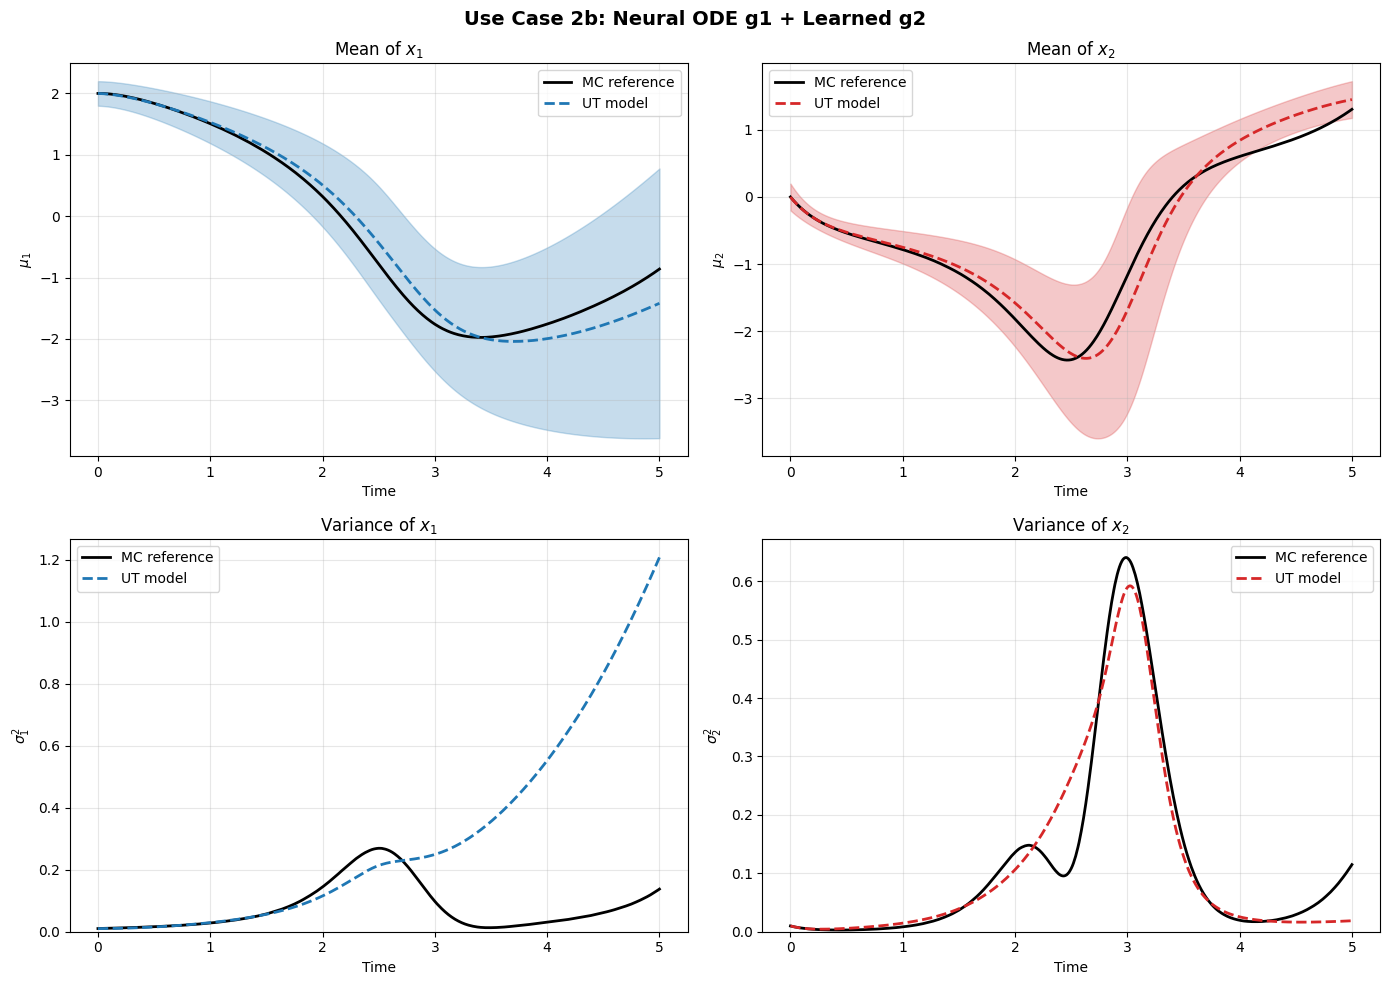

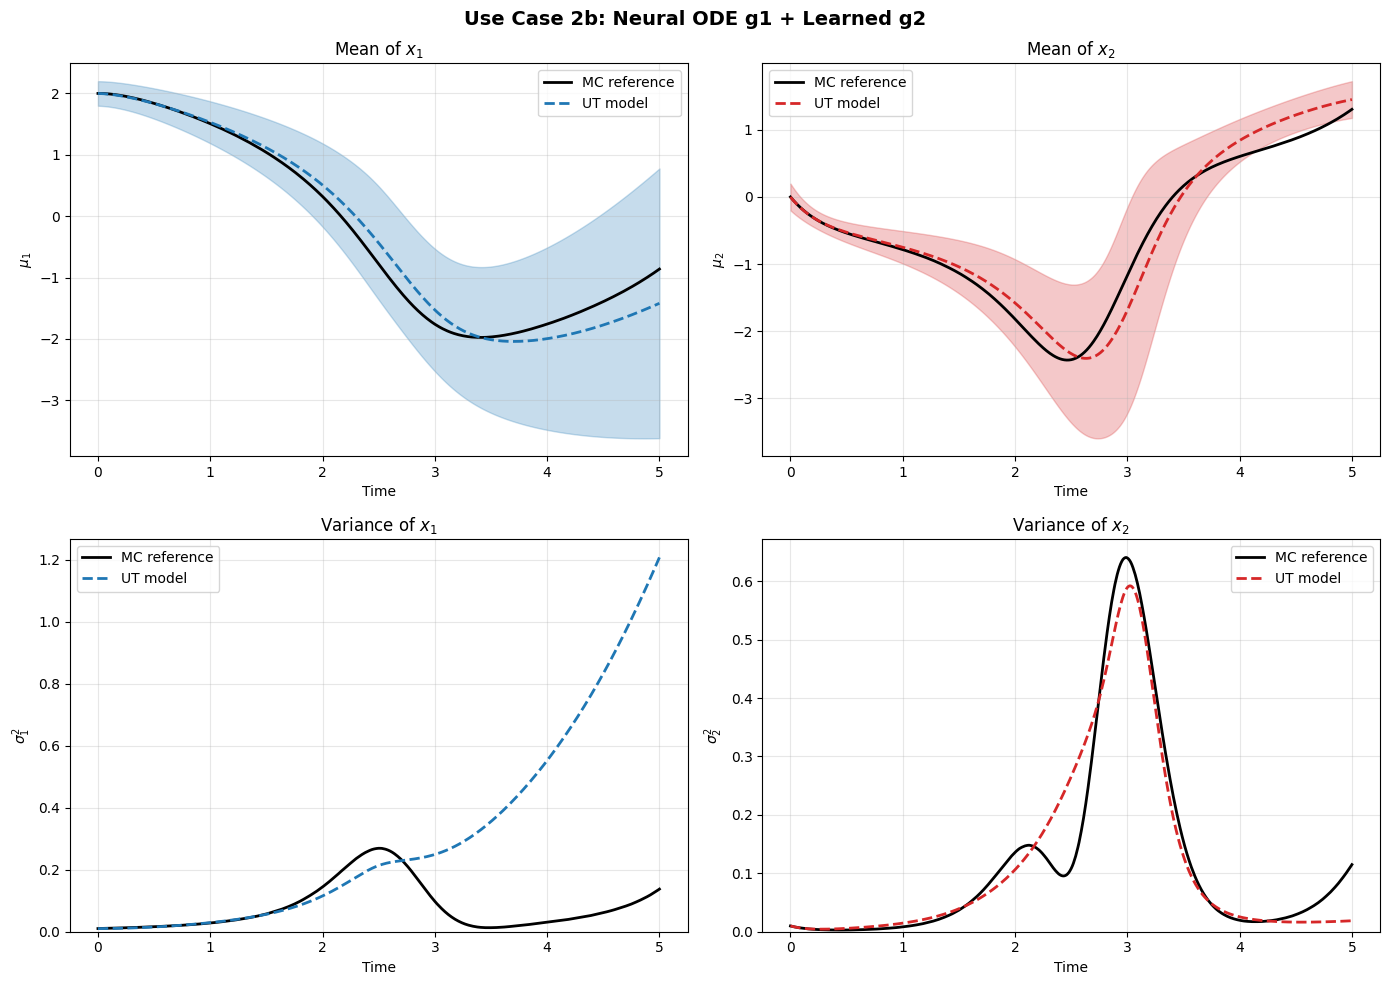

In [28]:
result_node = model_node.propagate([2.0, 0.0], [0.01, 0.01], n_steps=500)
mc_node = simulate_sde(gt_drift, [sigma_true]*nx, [2.0, 0.0], [0.01, 0.01],
                        5.0, dt, n_particles=10000, seed=42)

mse_mu = np.mean((result_node.mu - mc_node.mu)**2)
mse_var = np.mean((result_node.var - mc_node.var)**2)
print(f"Neural ODE g1 + Learned g2 vs MC ground truth:")
print(f"  Mean MSE:     {mse_mu:.6f}")
print(f"  Variance MSE: {mse_var:.6f}")

model_node.plot(result_node, reference=mc_node,
                title="Use Case 2b: Neural ODE g1 + Learned g2",
                dim_names=["$x_1$", "$x_2$"])


---
# Part 6: ContinuousUT — Use Case 3: Full System Identification

**Scenario:** We have stochastic data but *no knowledge* of the dynamics.
We learn both $g_{1,\theta_1}$ (drift MLP) and $g_{2,\theta_2}$ (diffusion MLP)
from moment-transition data.

**Two-phase training schedule:**
1. **Phase 1 — Drift warm-up:** Train $\theta_1$ with $g_2$ held at a constant
   value $\hat{\sigma}^2/2$ estimated from the data. $\theta_2$ frozen.
2. **Phase 2 — Joint training:** Unfreeze $\theta_2$, optimise $\theta_1, \theta_2$
   jointly.

This curriculum avoids the optimiser trying to learn drift and diffusion
simultaneously from a random initialisation.


In [29]:
print("Generating moment-transition data for Use Case 3...")
train_loader3, dev_loader3, dev_data3, (xn3, xn_next3) = generate_moment_data(
    drift_fn=gt_drift, sigma=sigma_true, nx=nx, base_x0=np.array([2.0, 0.0]),
    n_ensembles=512, n_particles=512, t_per_ensemble=2.0,
    dt=dt, batch_size=64, seed=42,
)


Generating moment-transition data for Use Case 3...
  Ensembles: 102/512
  Ensembles: 204/512
  Ensembles: 306/512
  Ensembles: 408/512
  Ensembles: 510/512
  Data: 81920 train, 20480 dev


In [31]:
result2

PropagationResult(time=array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.44, 0.45, 0.46, 0.47, 0.48, 0.49, 0.5 , 0.51, 0.52, 0.53, 0.54,
       0.55, 0.56, 0.57, 0.58, 0.59, 0.6 , 0.61, 0.62, 0.63, 0.64, 0.65,
       0.66, 0.67, 0.68, 0.69, 0.7 , 0.71, 0.72, 0.73, 0.74, 0.75, 0.76,
       0.77, 0.78, 0.79, 0.8 , 0.81, 0.82, 0.83, 0.84, 0.85, 0.86, 0.87,
       0.88, 0.89, 0.9 , 0.91, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97, 0.98,
       0.99, 1.  , 1.01, 1.02, 1.03, 1.04, 1.05, 1.06, 1.07, 1.08, 1.09,
       1.1 , 1.11, 1.12, 1.13, 1.14, 1.15, 1.16, 1.17, 1.18, 1.19, 1.2 ,
       1.21, 1.22, 1.23, 1.24, 1.25, 1.26, 1.27, 1.28, 1.29, 1.3 , 1.31,
       1.32, 1.33, 1.34, 1.35, 1.36, 1.37, 1.38, 1.39, 1.4 , 1.41, 1.42,
       1.43, 1.44, 1.45, 1.4

In [33]:
model3 = ContinuousUT.from_data(
    nx=nx, dt=dt,
    train_cfg=TrainingConfig(
        g1_warmup_epochs=40,
        joint_epochs=110,
        patience=30,
        verbosity=10,
    ),
)
model3.summary()

model3.fit(train_loader3, dev_loader3, dev_data3,
           sigma_from_data=(xn3, xn_next3))


ContinuousUT [Full System ID]
  nx=2  dt=0.01  g1=learned (MLP)  g2=learned
  params: g1=8,642  g2=4,482  trainable=13,124
  integrator: neuromancer RK4(h=0.01)
  trained: False
Estimated sigma: 0.1782 (per dim: [0.1844176  0.17200466])

Phase 1: Warmup -- training g1 with constant g2
None
Number of parameters: 8642
epoch: 0	train_loss: 3.2523519167e-07	dev_loss: 4.2214369955e-07
Interrupted training loop.

Phase 2: Training joint g1 + g2 (110 epochs)
None
Number of parameters: 13124
Interrupted training loop.
Training complete.


## 6.1 Evaluate: Full System ID

In [ ]:
result3 = model3.propagate(mu0, var0, n_steps=500)
mc3 = simulate_sde(gt_drift, [sigma_true]*nx, mu0, var0, 5.0, dt,
                    n_particles=10000, seed=42)

mse_mu = np.mean((result3.mu - mc3.mu)**2)
mse_var = np.mean((result3.var - mc3.var)**2)
print(f"Full System ID vs MC ground truth:")
print(f"  Mean MSE:     {mse_mu:.6f}")
print(f"  Variance MSE: {mse_var:.6f}")

model3.plot(result3, reference=mc3,
            title="Use Case 3: Full System ID (Learned g1 + g2)",
            dim_names=["$x_1$", "$x_2$"])


---
# Part 7: Side-by-Side Comparison

Compare all approaches on $x_1$: the whitebox drift (UC2), the neural ODE
drift (UC2b), and full system identification (UC3).


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (res, mc_ref, lbl) in zip(axes, [
    (result2, mc2, "UC2: Known drift\n+ learned diffusion"),
    (result_node, mc_node, "UC2b: Neural ODE drift\n+ learned diffusion"),
    (result3, mc3, "UC3: Full system ID\n(learned g1 + g2)"),
]):
    ax.plot(mc_ref.time, mc_ref.mu[:, 0], "k-", lw=1.5, label="MC truth")
    ax.plot(res.time, res.mu[:, 0], "b--", lw=1.5, label="UT model")
    lo, hi = res.confidence_band(2)
    ax.fill_between(res.time, lo[:, 0], hi[:, 0], alpha=0.2, color="blue")
    ax.set_title(lbl, fontsize=11); ax.set_xlabel("Time")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.suptitle("$x_1$ Mean + ±2σ Confidence Band: All Use Cases", fontweight="bold", fontsize=13)
plt.tight_layout(); plt.show()


---
## Summary

| Approach | What it gives you | What it needs |
|----------|-------------------|---------------|
| Standard Neural ODE | Mean trajectory only | Trajectory data |
| ContinuousUT (UC1) | Mean + variance from IC uncertainty | Known drift |
| ContinuousUT (UC2) | Mean + variance including diffusion | Known drift + moment data |
| ContinuousUT (UC2b) | Mean + variance (neural ODE as drift) | Trained neural ODE + moment data |
| ContinuousUT (UC3) | Mean + variance (everything learned) | Moment data only |

The ContinuousUT replaces expensive Monte Carlo ensembles with a single
deterministic ODE integration over the moments — typically **100–1000× faster** —
making uncertainty quantification practical for real-time and optimisation-in-the-loop
applications.


---
# Part 8: Error Analysis & Uncertainty Quantification

Now that we have results from all approaches, we provide a systematic toolkit for
evaluating the quality of the UT approximation. This section answers four questions:

1. **How accurate are the predicted moments?** — time-resolved MSE vs Monte Carlo
2. **Are the confidence bands calibrated?** — empirical coverage analysis
3. **What did the diffusion network learn?** — inspect $g_{2,\theta_2}$ across state space
4. **Where does error come from?** — decompose into drift error vs diffusion error


## 8.1 Time-Resolved Moment Error

We compare the UT-predicted mean and variance to the 10,000-particle Monte Carlo
reference at every time step.  This reveals *where in time* the approximation is
good or breaks down (e.g. near the nonlinear limit-cycle turn).


In [ ]:
def moment_error_analysis(result, mc_ref, label=""):
    """Compute and return time-resolved MSE for mean and variance."""
    mse_mu_t = np.mean((result.mu - mc_ref.mu)**2, axis=1)  # (T,)
    mse_var_t = np.mean((result.var - mc_ref.var)**2, axis=1)
    rmse_mu = np.sqrt(np.mean((result.mu - mc_ref.mu)**2))
    rmse_var = np.sqrt(np.mean((result.var - mc_ref.var)**2))
    max_mu_err = np.max(np.abs(result.mu - mc_ref.mu))
    max_var_err = np.max(np.abs(result.var - mc_ref.var))
    print(f"  {label}")
    print(f"    Mean  RMSE: {rmse_mu:.6f}   Max abs error: {max_mu_err:.6f}")
    print(f"    Var   RMSE: {rmse_var:.6f}   Max abs error: {max_var_err:.6f}")
    return mse_mu_t, mse_var_t

print("=== Moment Error Summary ===\n")
err2_mu, err2_var = moment_error_analysis(result2, mc2, "UC2: Known drift + learned g2")
err_node_mu, err_node_var = moment_error_analysis(result_node, mc_node, "UC2b: Neural ODE drift + learned g2")
err3_mu, err3_var = moment_error_analysis(result3, mc3, "UC3: Full system ID")

# Time-resolved plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for err_mu, err_var, lbl, c in [
    (err2_mu, err2_var, "UC2: Known drift", "tab:blue"),
    (err_node_mu, err_node_var, "UC2b: Neural ODE", "tab:orange"),
    (err3_mu, err3_var, "UC3: Full sys ID", "tab:green"),
]:
    axes[0].plot(result2.time, err_mu, color=c, lw=1.5, label=lbl)
    axes[1].plot(result2.time, err_var, color=c, lw=1.5, label=lbl)
axes[0].set_title("Mean MSE over time"); axes[0].set_xlabel("Time"); axes[0].set_ylabel("MSE")
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_yscale("log")
axes[1].set_title("Variance MSE over time"); axes[1].set_xlabel("Time"); axes[1].set_ylabel("MSE")
axes[1].legend(); axes[1].grid(True, alpha=0.3); axes[1].set_yscale("log")
plt.suptitle("Time-Resolved Moment Error (vs 10k-particle MC)", fontweight="bold")
plt.tight_layout(); plt.show()


## 8.2 Confidence Band Calibration

A well-calibrated model's $\pm n\sigma$ bands should contain approximately the
expected fraction of MC particles.  For Gaussian marginals:
- $\pm 1\sigma$ should contain ~68% of particles
- $\pm 2\sigma$ should contain ~95%
- $\pm 3\sigma$ should contain ~99.7%

We run the MC simulation and check what fraction of particles actually fall
inside the UT bands at each time step.


Running calibration analysis for UC2 (known drift + learned g2)...
Running calibration analysis for UC2b (neural ODE + learned g2)...


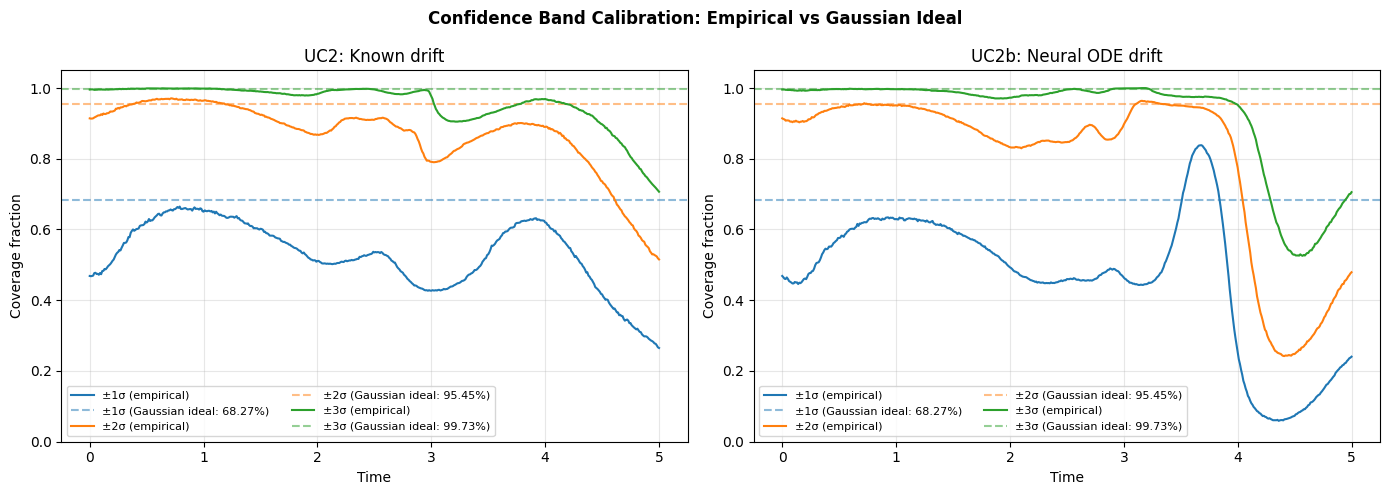


UC2 — Mean coverage over trajectory:
  ±1σ:  empirical=0.529  ideal=0.683  gap=-0.154
  ±2σ:  empirical=0.869  ideal=0.954  gap=-0.085
  ±3σ:  empirical=0.957  ideal=0.997  gap=-0.040

UC2b — Mean coverage over trajectory:
  ±1σ:  empirical=0.463  ideal=0.683  gap=-0.220
  ±2σ:  empirical=0.800  ideal=0.954  gap=-0.155
  ±3σ:  empirical=0.923  ideal=0.997  gap=-0.074


In [38]:
def calibration_analysis(result, drift_fn, sigmas, mu0, var0, t_final, dt,
                        n_particles=5000, seed=123):
    """Check empirical coverage of UT confidence bands against MC particles."""
    np.random.seed(seed)
    nx_dim = len(mu0)
    mu0_arr = np.asarray(mu0, dtype=np.float64)
    var0_arr = np.asarray(var0, dtype=np.float64)
    sigmas_arr = np.asarray(sigmas, dtype=np.float64)
    n_steps = len(result.time) - 1

    # Simulate particles
    x = mu0_arr + np.sqrt(var0_arr) * np.random.randn(n_particles, nx_dim)
    particles = [x.copy()]
    drift_fn.eval()
    with torch.no_grad():
        for _ in range(n_steps):
            d = drift_fn(torch.tensor(x, dtype=torch.float32)).numpy()
            x = x + d * dt + sigmas_arr * np.random.randn(n_particles, nx_dim) * np.sqrt(dt)
            particles.append(x.copy())
    particles = np.array(particles)  # (T, n_particles, nx)

    # Check coverage for different sigma levels
    coverages = {}
    for n_sig in [1, 2, 3]:
        lo, hi = result.confidence_band(n_sig)
        # For each time step, what fraction of particles are inside [lo, hi] for ALL dims?
        inside = np.ones((len(result.time), n_particles), dtype=bool)
        for d in range(nx_dim):
            inside &= (particles[:, :, d] >= lo[:, d:d+1]) & (particles[:, :, d] <= hi[:, d:d+1])
        frac = inside.mean(axis=1)  # (T,)
        coverages[n_sig] = frac

    return coverages, particles

print("Running calibration analysis for UC2 (known drift + learned g2)...")
cov2, particles2 = calibration_analysis(
    result2, gt_drift, [sigma_true]*nx, mu0, var0, 5.0, dt
)

print("Running calibration analysis for UC2b (neural ODE + learned g2)...")
cov_node, particles_node = calibration_analysis(
    result_node, gt_drift, [sigma_true]*nx, [2.0, 0.0], [0.01, 0.01], 5.0, dt
)

# Expected coverages for Gaussian
from scipy.stats import norm
expected = {1: norm.cdf(1) - norm.cdf(-1),  # 0.6827
            2: norm.cdf(2) - norm.cdf(-2),  # 0.9545
            3: norm.cdf(3) - norm.cdf(-3)}  # 0.9973

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, covs, title in [(axes[0], cov2, "UC2: Known drift"),
                         (axes[1], cov_node, "UC2b: Neural ODE drift")]:
    for n_sig, color in [(1, "tab:blue"), (2, "tab:orange"), (3, "tab:green")]:
        ax.plot(result2.time, covs[n_sig], color=color, lw=1.5,
                label=f"±{n_sig}σ (empirical)")
        ax.axhline(expected[n_sig], color=color, ls="--", alpha=0.5,
                   label=f"±{n_sig}σ (Gaussian ideal: {expected[n_sig]:.2%})")
    ax.set_title(title); ax.set_xlabel("Time"); ax.set_ylabel("Coverage fraction")
    ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.05)
plt.suptitle("Confidence Band Calibration: Empirical vs Gaussian Ideal", fontweight="bold")
plt.tight_layout(); plt.show()

# Summary stats
for label, covs in [("UC2", cov2), ("UC2b", cov_node)]:
    print(f"\n{label} — Mean coverage over trajectory:")
    for n_sig in [1, 2, 3]:
        emp = covs[n_sig].mean()
        ideal = expected[n_sig]
        print(f"  ±{n_sig}σ:  empirical={emp:.3f}  ideal={ideal:.3f}  gap={emp-ideal:+.3f}")


## 8.5 Quick UQ Report

A one-call function that produces a complete uncertainty quantification report
for any `PropagationResult`. Copy this into your own workflows.


In [42]:
def uq_report(result, mc_ref=None, label="Model", n_sigma=2):
    """
    Print a compact UQ report for a PropagationResult.

    Args:
        result: PropagationResult from model.propagate()
        mc_ref: optional PropagationResult from simulate_sde() for comparison
        label: display name
        n_sigma: sigma level for band analysis
    """
    nx = result.mu.shape[1]
    lo, hi = result.confidence_band(n_sigma)
    band_width = (hi - lo).mean(axis=0)  # average band width per dim

    print(f"\n{'=' * 60}")
    print(f"  UQ Report: {label}")
    print(f"{'=' * 60}")
    print(f"  Time horizon:    {result.time[-1]:.2f}s  ({len(result.time)} steps)")
    print(f"  State dimension: {nx}")
    print(f"  Final mean:      {result.mu[-1]}")
    print(f"  Final std:       {result.std()[-1]}")
    print(f"  Avg ±{n_sigma}σ band width: {band_width}")

    # Growth analysis
    var_growth = result.var[-1] / np.maximum(result.var[0], 1e-12)
    print(f"  Variance growth factor: {var_growth}")

    max_var_time = result.time[np.argmax(result.var.max(axis=1))]
    print(f"  Peak variance at t={max_var_time:.2f}s")

    if mc_ref is not None:
        rmse_mu = np.sqrt(np.mean((result.mu - mc_ref.mu)**2))
        rmse_var = np.sqrt(np.mean((result.var - mc_ref.var)**2))
        max_mu_err = np.max(np.abs(result.mu - mc_ref.mu))
        final_mu_err = np.linalg.norm(result.mu[-1] - mc_ref.mu[-1])
        print(f"  --- vs MC reference ---")
        print(f"  Mean RMSE:       {rmse_mu:.6f}")
        print(f"  Variance RMSE:   {rmse_var:.6f}")
        print(f"  Max mean error:  {max_mu_err:.6f}")
        print(f"  Final mean error:{final_mu_err:.6f}")
    print(f"{'=' * 60}")

# Run reports for all models
uq_report(result2, mc2, "UC2: Known drift + learned g2")
uq_report(result_node, mc_node, "UC2b: Neural ODE + learned g2")
uq_report(result3, mc3, "UC3: Full system ID")



  UQ Report: UC2: Known drift + learned g2
  Time horizon:    5.00s  (501 steps)
  State dimension: 2
  Final mean:      [-0.765936   1.2359397]
  Final std:       [0.44368792 0.10943809]
  Avg ±2σ band width: [1.3610377 0.8671268]
  Variance growth factor: [19.685896   1.1976696]
  Peak variance at t=2.86s
  --- vs MC reference ---
  Mean RMSE:       0.064097
  Variance RMSE:   0.105149
  Max mean error:  0.121518
  Final mean error:0.118278

  UQ Report: UC2b: Neural ODE + learned g2
  Time horizon:    5.00s  (501 steps)
  State dimension: 2
  Final mean:      [-1.41892  1.45251]
  Final std:       [1.0986193  0.13695806]
  Avg ±2σ band width: [1.8675057 1.0950267]
  Variance growth factor: [120.69644     1.8757514]
  Peak variance at t=5.00s
  --- vs MC reference ---
  Mean RMSE:       0.233968
  Variance RMSE:   0.279002
  Max mean error:  0.558334
  Final mean error:0.577016

  UQ Report: UC3: Full system ID
  Time horizon:    5.00s  (501 steps)
  State dimension: 2
  Final mean: